# Consigna

Senoidal de frecuencia 
potencia normalizada, es decir energía (o varianza) unitaria
Se pide:

a) Sea <math xmlns="http://www.w3.org/1998/Math/MathML">
  <msub>
    <mi>k</mi>
    <mn>0</mn>
  </msub>
  <mo>=</mo>
  <mo fence="false" stretchy="false">{</mo>
  <mi>N</mi>
  <mrow data-mjx-texclass="ORD">
    <mo>/</mo>
  </mrow>
  <mn>4</mn>
  <mo>,</mo>
  <mi>N</mi>
  <mrow data-mjx-texclass="ORD">
    <mo>/</mo>
  </mrow>
  <mn>4</mn>
  <mo>+</mo>
  <mn>0.25</mn>
  <mo>,</mo>
  <mi>N</mi>
  <mrow data-mjx-texclass="ORD">
    <mo>/</mo>
  </mrow>
  <mn>4</mn>
  <mo>+</mo>
  <mn>0.5</mn>
  <mo fence="false" stretchy="false">}</mo>
</math>
. Notar que a cada senoidal se le agrega una pequeña desintonía respecto a  <math xmlns="http://www.w3.org/1998/Math/MathML">
  <msub>
    <mi mathvariant="normal">&#x394;</mi>
    <mi>f</mi>
  </msub>
</math>
. Graficar las tres densidades espectrales de potencia (PDS's) y discutir cuál es el efecto de dicha desintonía en el espectro visualizado.

b) Verificar la potencia unitaria de cada PSD. En base a la teoría estudiada, ¿cuál es la razón por la cual una señal senoidal tiene un espectro (PSD) tan diferente respecto a otra de muy pocos Hertz de diferencia?



# Funciones Previas

Funciones de resoluciones anteriores. Para un uso correcto deberían guardarse en un archivo Python (.py) en una carpeta lib para utilización como librerías. 

A fines prácticos, se copiarán acá

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def mi_funcion_sen( vmax = 1, dc = 0, ff = 1, ph = 0, nn = 100, fs = 1000 ) -> tuple[np.ndarray,np.ndarray]:
    ts = 1/fs
    tt: np.ndarray = np.arange(stop=nn*ts, step=ts)

    xx = vmax * np.sin(2*np.pi*ff*tt + ph) + dc
    xx = np.array(xx).reshape(nn,1)
    tt = tt.reshape(nn,1)

    return xx, tt

def mi_funcion_cuadrada(vmax = 1, dc = 0, ff = 1, duty = .5, nn = 100, fs = 1000 ) -> tuple[np.ndarray,np.ndarray] :
    ts = 1/fs
    tt: np.ndarray = np.arange(stop=nn*ts, step=ts)

    xx = np.where(tt % (1/ff) < (1/ff) * duty, 1, -1)
    xx = vmax * xx + dc
    #signal.square(2* np.pi * ff* tt, duty)

    tt = tt.reshape(nn,1)
    xx = np.array(xx).reshape(nn,1)

    return xx, tt

def mi_funcion_triangular(vmax = 1, dc = 0, ff = 1, nn = 1, fs = 1000) -> tuple[np.ndarray,np.ndarray]:
    ts = 1/fs
    tt: np.ndarray = np.arange(stop= nn*ts, step=ts)
    T = 1/ff

    xx = [((vmax/T) * (i%T) + dc) for i in tt]
    #signal.sawtooth(2* np.pi * ff* tt, 0.5)

    tt = tt.reshape(nn,1)
    xx = np.array(xx).reshape(nn,1)

    return xx, tt

def noise_generator(Pn = 1, nn = 100, fs = 1000) -> tuple[np.ndarray,np.ndarray]:
    '''noise_generator(Pn = 1, nn = 100, fs = 1000) -> tuple[np.ndarray,np.ndarray]:
        Generates Gaussian noise, with variance Pn and zero mean.

        Note: This distribution corresponds to "white noise". (Extracted from ASYS notes, Stochastic process - White Noise)
    '''
    ts = 1/fs
    tt: np.ndarray = np.arange(stop=nn*ts, step=ts)

    xx = np.random.normal(loc=0, scale=np.sqrt(Pn), size=nn)

    tt = tt.reshape(nn,1)
    xx = np.array(xx).reshape(nn,1)

    return xx, tt

def mi_sen_ruidosa( vmax = 1, dc = 0, ff = 1, ph = 0, nn = 100, fs = 1000, snr = 20) -> tuple[np.ndarray,np.ndarray]:
    xx, tt = mi_funcion_sen(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=nn, fs=fs)
    pot_sig = np.mean(xx**2)
    var_noise = ((vmax**2)/2) / (10**(snr/10))  # Calculando potencia de señal conocida "senoidal"
    # var_noise = power(xx) / (10**(snr/10))    # Lo mismo, calculando potencia por definicion
    
    noise, _ = noise_generator(var_noise, nn, fs)
    xx = xx + noise

    return xx, tt

def power(x: np.ndarray) -> float:
    return np.mean(x**2)

def snr(signal: np.ndarray, noise: np.ndarray) -> float:
    return 10 * np.log10(np.mean(signal**2) / np.mean(noise**2))

def mi_adc(xx, Vfs, bits=4):
    '''mi_adc
    Quantizes the signal xx like an ADC with Vfs and bits.
    xx: Signal to be quantized.
    Vfs: ADC [0, Vfs]
    bits: Number of bits of the ADC.
    ''' 
    q = Vfs/(2**bits) 
    xq = np.round(xx/q) * q
    vmax =  q*(2**(bits-1)-1)
    vmin = -q*2**(bits-1)

    np.clip(xq, vmin, vmax, out=xq)
    #xq[xq > vmax] = vmax
    #xq[xq < vmin] = vmin
    return xq

def autocorrelate(xx: np.ndarray) -> np.ndarray:
    xx = np.asarray(xx).flatten()

    autocorr = np.correlate(xx, xx, mode='full')/xx.size        # Normalizated to size. Gives the true values of the autocorrelation
    autocorr = autocorr[autocorr.size//2:]                      # Only keep non negative values
    autocorr = autocorr.reshape(-1,1)                           # Reshape to column vector (standard of PDS)
    return autocorr

def mod_db(xx: np.ndarray) -> np.ndarray:
    return 20*np.log10(np.abs(xx))

def mod_dbw(xx: np.ndarray) -> np.ndarray:
    return 10*np.log10(np.abs(xx))

def freq_axis(xx: np.ndarray, fs: float) -> np.ndarray:
    '''freq_axis
    
    Equal to np.fft.fftfreq. It generates the correct freq axis for the fft algorithm.
    Axis has the form:
    [0, △f, 2△f, ..., fs/2, -fs/2, -(fs/2-△f), ..., -△f]
    Note: the positive half always starts with 0. The negative half always starts with -fs/2, so, the negative half has one extra value if the length of the signal is even.
    xx: signal to generate the axis for. Only the length is used.
    fs: sampling frequency
    '''
    nn = xx.shape[0]
    half = np.arange(0, fs/2, fs/nn)
    ff = np.concatenate((half, -half[::-1] - fs/nn))
    ff = ff[:nn]
    return ff.reshape(-1,1)

# Respuesta

Funciones de resoluciones anteriores. Para un uso correcto deberían guardarse en un archivo Python (.py) en una carpeta lib para utilización como librerías. 

A fines prácticos, se copiarán acá

## Prueba 1:

Se realiza una prueba con una señal senoidal normalizada a 1W, pasada por un ADC.

In [3]:
##### Variables
vmax = 2**.5    # Vpico
ph = 0          # Fase inicial
N = 2000        # Cant Muestras
fs = 2000       # Freq muestreo

delta_f = fs/N
k0 = np.array([N/4, N/4 + .25, N/4 + .5])
freqs = k0 * delta_f   # Freq

##### Funciones
xx = []
for freq in freqs:
    xx_aux, _ = mi_funcion_sen(vmax, ff=freq, ph=ph,  nn=N, fs=fs)
    xx.append(xx_aux)

t = np.arange(stop=N/fs, step=1/fs).reshape(-1,1)



Nota: La PSD, por definición, se puede calcular como la transformada de fourier de la autocorrelación. Esta definición se utilizará para obtener la PSD de un proceso estocástico (Ruido).


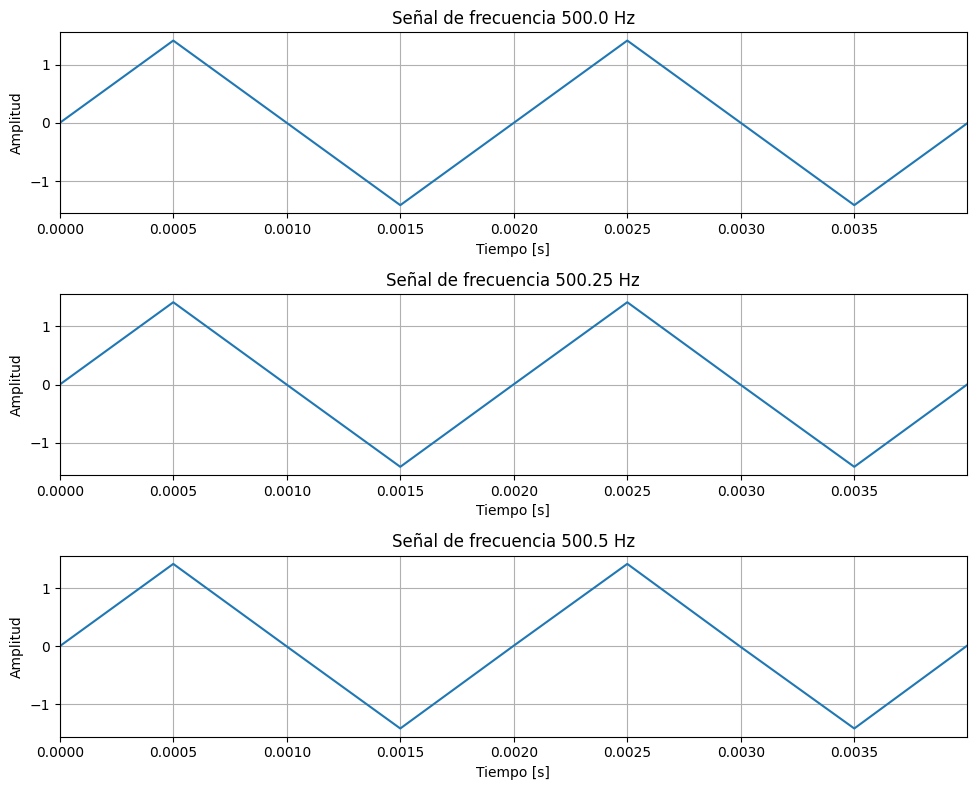

In [4]:
##### Gráficos
plt.figure(figsize=(10,8))

plt.subplot(3,1,1)
plt.plot(t, xx[0])
plt.xlim(0,2/freqs[2])

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title(f"Señal de frecuencia {freqs[0]} Hz")
plt.tight_layout()
plt.grid()

# Señal de Error #####
plt.subplot(3,1,2)
plt.plot(t, xx[1])
plt.xlim(0,2/freqs[2])

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title(f"Señal de frecuencia {freqs[1]} Hz")
plt.tight_layout()
plt.grid()


plt.subplot(3,1,3)
plt.plot(t, xx[2])
plt.xlim(0,2/freqs[2])

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title(f"Señal de frecuencia {freqs[2]} Hz")
plt.tight_layout()
plt.grid()


plt.show()


**Gráfico de las 3 FFT**

Se muestra el espectro completo para que se observe claramente el efecto del desparramo de potencia

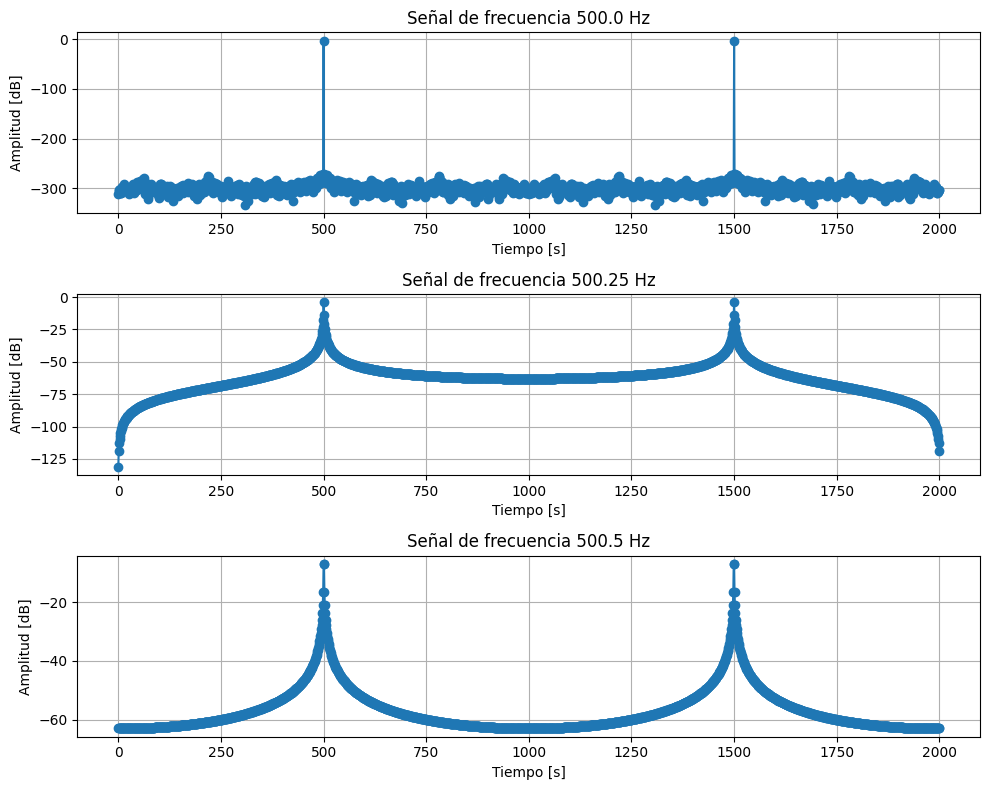

In [5]:
xx_fft = [np.fft.fft(x, axis=0)/len(x) for x in xx]

abs_xx_fft = [mod_db(fft) for fft in xx_fft]

plt.figure(figsize=(10,8))

plt.subplot(3,1,1)
plt.plot(abs_xx_fft[0], "-o")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [dB]")
plt.title(f"Señal de frecuencia {freqs[0]} Hz")
plt.tight_layout()
plt.grid()

plt.subplot(3,1,2)
plt.plot(abs_xx_fft[1], "-o")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [dB]")
plt.title(f"Señal de frecuencia {freqs[1]} Hz")
plt.tight_layout()
plt.grid()

plt.subplot(3,1,3)
plt.plot(abs_xx_fft[2], "-o")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [dB]")
plt.title(f"Señal de frecuencia {freqs[2]} Hz")
plt.tight_layout()
plt.grid()


plt.show()

**Gráfico de las 3 FFT en frecuencia de interes**

Se muestra el espectro en frecuencias cercanas a la de interés (500Hz)

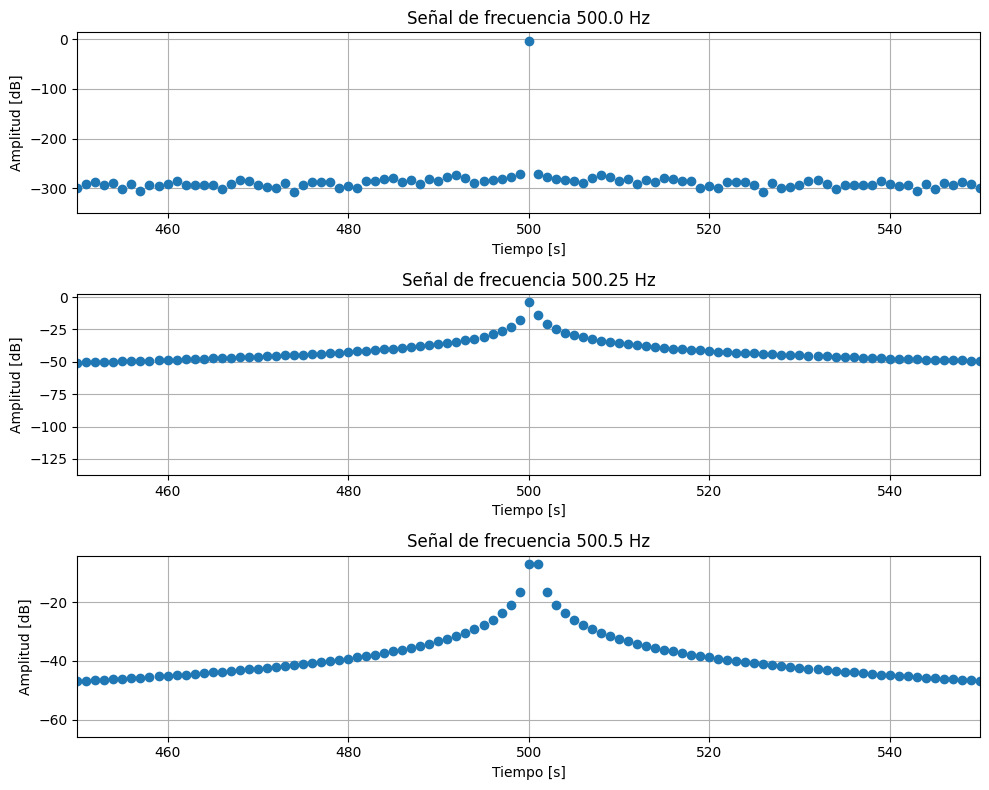

Valor en 500 Hz para F=500 Hz: -3.01 dB
Valor en 500 Hz para F=500.25 Hz: -3.93 dB
Valor en 500 Hz para F=500.5 Hz: -6.93 dB


In [6]:
xx_fft = [np.fft.fft(x, axis=0)/len(x) for x in xx]
ff = freq_axis(xx[0], fs)

abs_xx_fft = [mod_db(fft) for fft in xx_fft]

plt.figure(figsize=(10,8))

plt.subplot(3,1,1)
plt.plot(abs_xx_fft[0], "o")
plt.xlim(450, 550)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [dB]")
plt.title(f"Señal de frecuencia {freqs[0]} Hz")
plt.tight_layout()
plt.grid()

plt.subplot(3,1,2)
plt.plot(abs_xx_fft[1], "o")
plt.xlim(450, 550)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [dB]")
plt.title(f"Señal de frecuencia {freqs[1]} Hz")
plt.tight_layout()
plt.grid()

plt.subplot(3,1,3)
plt.plot(abs_xx_fft[2], "o")
plt.xlim(450, 550)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [dB]")
plt.title(f"Señal de frecuencia {freqs[2]} Hz")
plt.tight_layout()
plt.grid()


plt.show()

print(f"Valor en 500 Hz para F=500 Hz: {abs_xx_fft[0][500][0]:.2f} dB")
print(f"Valor en 500 Hz para F=500.25 Hz: {abs_xx_fft[1][500][0]:.2f} dB")
print(f"Valor en 500 Hz para F=500.5 Hz: {abs_xx_fft[2][500][0]:.2f} dB")

Se observan pisos de ruido muy distintos entre las 3 señales ya que la potencia de la senoidal no ses encuentra perfectamente alineada con una de las muestras, sino que se encuentra entre 2 bins. 
Esto es lo más parecido a la realidad, donde una muy pequeña diferencia puede generar que veamos una forma más suavizada en contraste a la delta de la primer gráfica.

Piso de ruido ideal: ~ -300dB
Piso de ruido +.25: ~ -50dB
Piso de ruido +.5: ~ -45dB

## Prueba 2: Ventaneo

En las pruebas anteriores se estuvo utilizando una ventana con forma de pulso unitario (sin ventana, tomando las muestras directamete).
El algoritmo de DFT periodiza la señal que se está evaluando, por lo tanto, se generan discontinuidades si no se muestrean periodos exactos y completos de la señal (desparramo de frecuencia).

A continuación, se realizará el mismo tratamiento anterior pero con distintas ventanas

In [7]:
from scipy import signal

##### Variables
vmax = 2**.5    # Vpico
ph = 0          # Fase inicial
N = 2000        # Cant Muestras
fs = 2000       # Freq muestreo

delta_f = fs/N
k0 = np.array([N/4, N/4 + .25, N/4 + .5])

freqs = k0 * delta_f   # Freq

##### Funciones
xx = []
for freq in freqs:
    xx_aux, _ = mi_funcion_sen(vmax, ff=freq, ph=ph,  nn=N, fs=fs)
    xx.append(xx_aux)



**Ventana Hann**

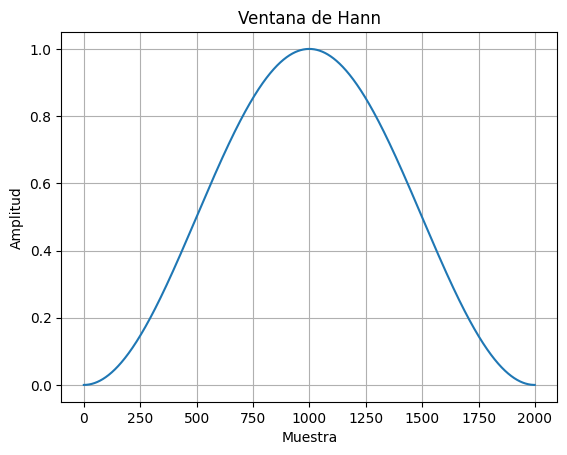

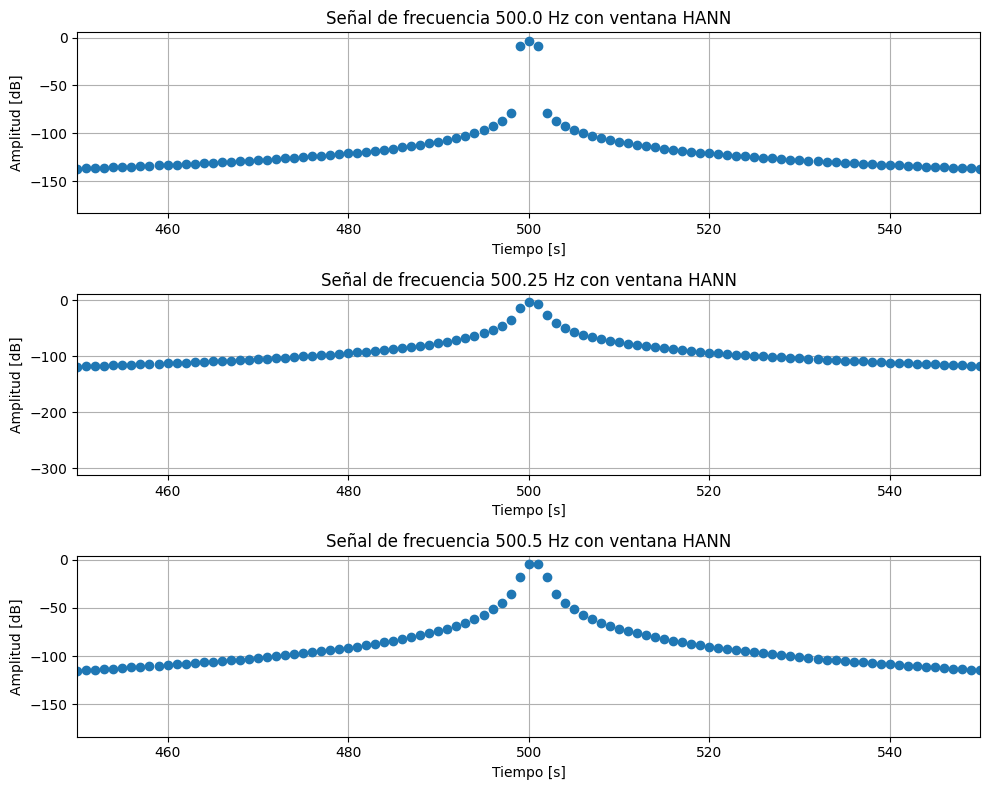

Valor en 500 Hz para F=500 Hz: -3.01 dB
Valor en 500 Hz para F=500.25 Hz: -3.36 dB
Valor en 500 Hz para F=500.5 Hz: -4.43 dB


In [8]:
##### Aplicacion de ventana
window = signal.windows.hann(N).reshape(-1,1)
err_window = window.mean()
xx_windowed = [x * window for x in xx]

plt.plot(window)
plt.title("Ventana de Hann")
plt.xlabel("Muestra")
plt.ylabel("Amplitud")
plt.grid()

##### FFT
xx_fft = [np.fft.fft(x, axis=0)/(len(x)*err_window) for x in xx_windowed]
abs_xx_fft = [mod_db(fft) for fft in xx_fft]

##### Gráficos
plt.figure(figsize=(10,8))

plt.subplot(3,1,1)
plt.plot(abs_xx_fft[0], "o")
plt.xlim(450, 550)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [dB]")
plt.title(f"Señal de frecuencia {freqs[0]} Hz con ventana HANN")
plt.tight_layout()
plt.grid()

plt.subplot(3,1,2)
plt.plot(abs_xx_fft[1], "o")
plt.xlim(450, 550)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [dB]")
plt.title(f"Señal de frecuencia {freqs[1]} Hz con ventana HANN")
plt.tight_layout()
plt.grid()

plt.subplot(3,1,3)
plt.plot(abs_xx_fft[2], "o")
plt.xlim(450, 550)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [dB]")
plt.title(f"Señal de frecuencia {freqs[2]} Hz con ventana HANN")
plt.tight_layout()
plt.grid()


plt.show()

print(f"Valor en 500 Hz para F=500 Hz: {abs_xx_fft[0][500][0]:.2f} dB")
print(f"Valor en 500 Hz para F=500.25 Hz: {abs_xx_fft[1][500][0]:.2f} dB")
print(f"Valor en 500 Hz para F=500.5 Hz: {abs_xx_fft[2][500][0]:.2f} dB")


**Ventana Hamming**

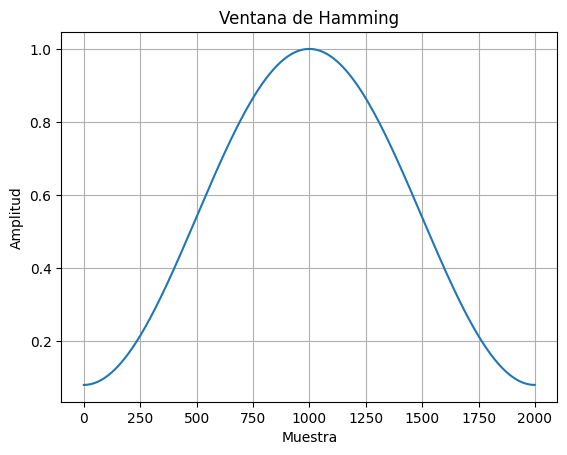

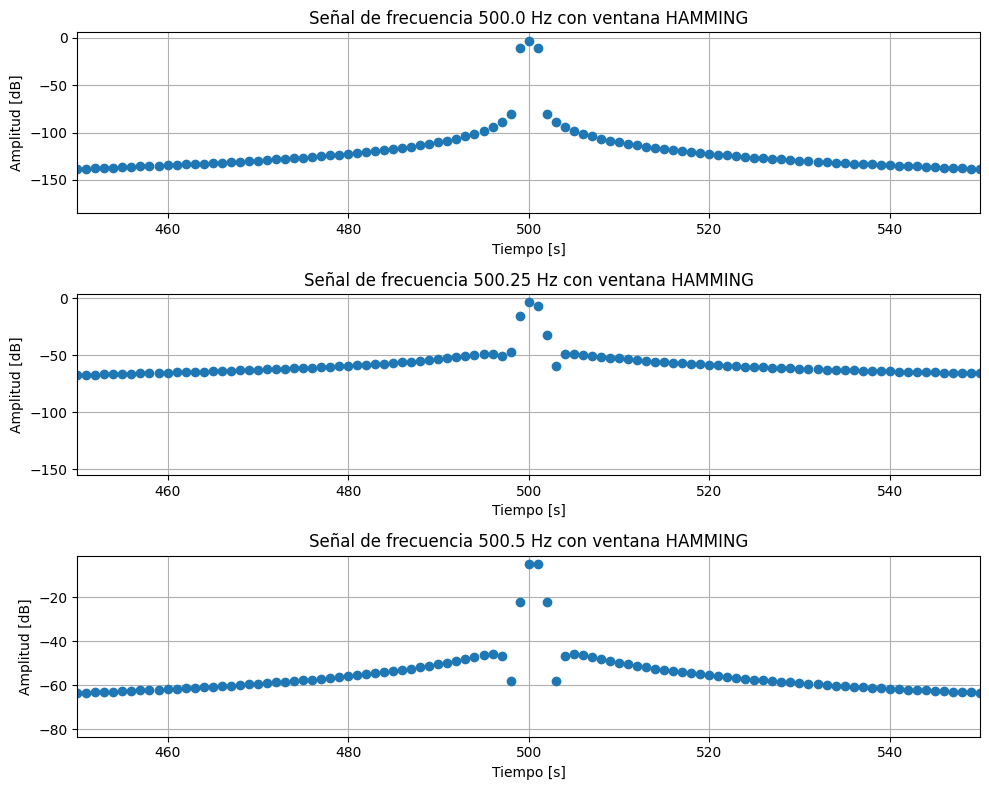

Valor en 500 Hz para F=500 Hz: -3.01 dB
Valor en 500 Hz para F=500.25 Hz: -3.44 dB
Valor en 500 Hz para F=500.5 Hz: -4.76 dB


In [9]:
##### Aplicacion de ventana
window = signal.windows.hamming(N).reshape(-1,1)
err_window = window.mean()
xx_windowed = [x * window for x in xx]

plt.plot(window)
plt.title("Ventana de Hamming")
plt.xlabel("Muestra")
plt.ylabel("Amplitud")
plt.grid()

##### FFT
xx_fft = [np.fft.fft(x, axis=0)/(len(x)*err_window) for x in xx_windowed]
abs_xx_fft = [mod_db(fft) for fft in xx_fft]

##### Gráficos
plt.figure(figsize=(10,8))

plt.subplot(3,1,1)
plt.plot(abs_xx_fft[0], "o")
plt.xlim(450, 550)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [dB]")
plt.title(f"Señal de frecuencia {freqs[0]} Hz con ventana HAMMING")
plt.tight_layout()
plt.grid()

plt.subplot(3,1,2)
plt.plot(abs_xx_fft[1], "o")
plt.xlim(450, 550)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [dB]")
plt.title(f"Señal de frecuencia {freqs[1]} Hz con ventana HAMMING")
plt.tight_layout()
plt.grid()

plt.subplot(3,1,3)
plt.plot(abs_xx_fft[2], "o")
plt.xlim(450, 550)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [dB]")
plt.title(f"Señal de frecuencia {freqs[2]} Hz con ventana HAMMING")
plt.tight_layout()
plt.grid()


plt.show()

print(f"Valor en 500 Hz para F=500 Hz: {abs_xx_fft[0][500][0]:.2f} dB")
print(f"Valor en 500 Hz para F=500.25 Hz: {abs_xx_fft[1][500][0]:.2f} dB")
print(f"Valor en 500 Hz para F=500.5 Hz: {abs_xx_fft[2][500][0]:.2f} dB")


**Ventana Blackmann**

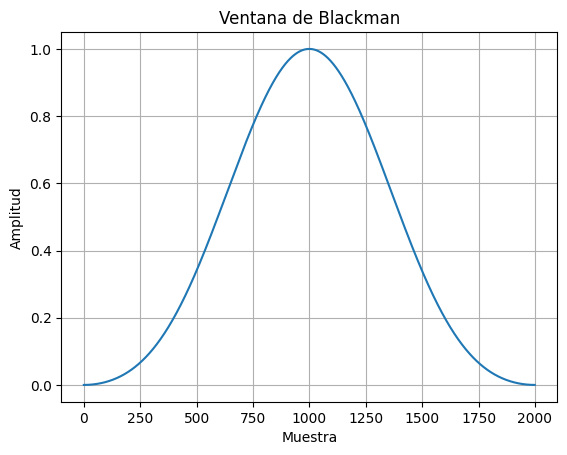

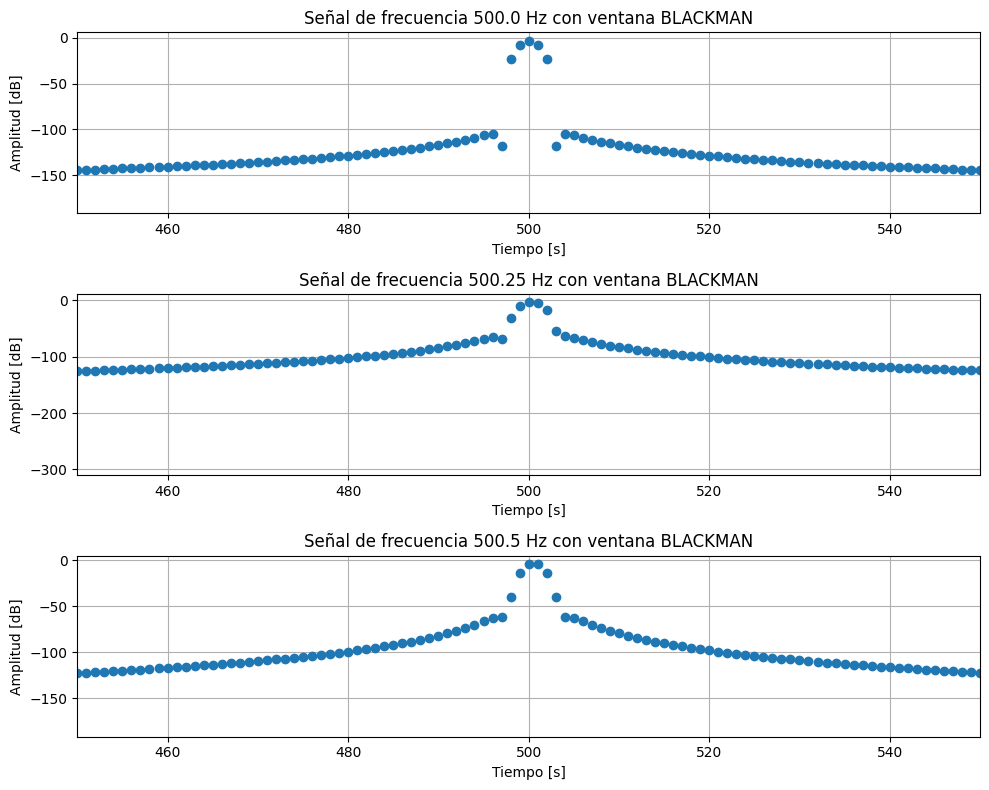

Valor en 500 Hz para F=500 Hz: -3.01 dB
Valor en 500 Hz para F=500.25 Hz: -3.28 dB
Valor en 500 Hz para F=500.5 Hz: -4.11 dB


In [10]:
##### Aplicacion de ventana
window = signal.windows.blackman(N).reshape(-1,1)
err_window = window.mean()
xx_windowed = [x * window for x in xx]

plt.plot(window)
plt.title("Ventana de Blackman")
plt.xlabel("Muestra")
plt.ylabel("Amplitud")
plt.grid()

##### FFT
xx_fft = [np.fft.fft(x, axis=0)/(len(x)*err_window) for x in xx_windowed]
abs_xx_fft = [mod_db(fft) for fft in xx_fft]

##### Gráficos
plt.figure(figsize=(10,8))

plt.subplot(3,1,1)
plt.plot(abs_xx_fft[0], "o")
plt.xlim(450, 550)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [dB]")
plt.title(f"Señal de frecuencia {freqs[0]} Hz con ventana BLACKMAN")
plt.tight_layout()
plt.grid()

plt.subplot(3,1,2)
plt.plot(abs_xx_fft[1], "o")
plt.xlim(450, 550)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [dB]")
plt.title(f"Señal de frecuencia {freqs[1]} Hz con ventana BLACKMAN")
plt.tight_layout()
plt.grid()

plt.subplot(3,1,3)
plt.plot(abs_xx_fft[2], "o")
plt.xlim(450, 550)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [dB]")
plt.title(f"Señal de frecuencia {freqs[2]} Hz con ventana BLACKMAN")
plt.tight_layout()
plt.grid()


plt.show()

print(f"Valor en 500 Hz para F=500 Hz: {abs_xx_fft[0][500][0]:.2f} dB")
print(f"Valor en 500 Hz para F=500.25 Hz: {abs_xx_fft[1][500][0]:.2f} dB")
print(f"Valor en 500 Hz para F=500.5 Hz: {abs_xx_fft[2][500][0]:.2f} dB")


**Ventana Flattop**

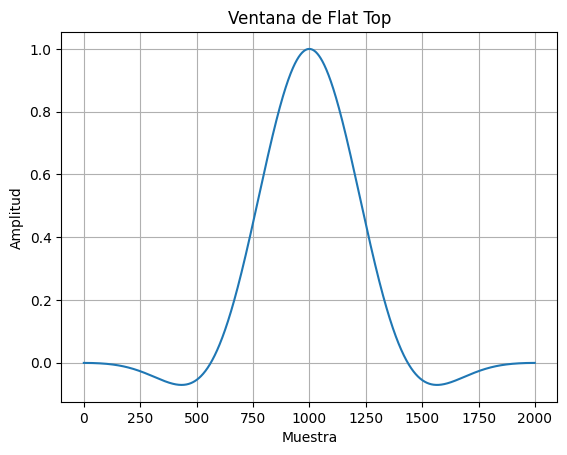

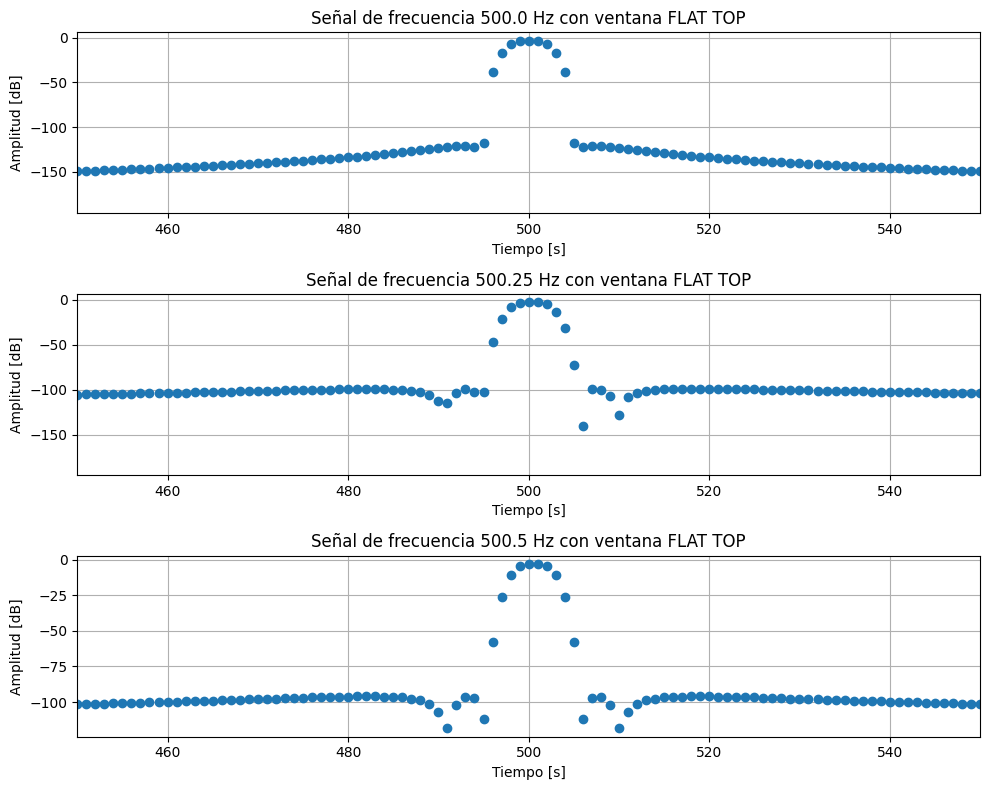

Valor en 500 Hz para F=500 Hz: -3.01 dB
Valor en 500 Hz para F=500.25 Hz: -3.01 dB
Valor en 500 Hz para F=500.5 Hz: -3.02 dB


In [11]:
## Aplicacion de ventana
window = signal.windows.flattop(N).reshape(-1,1)
err_window = window.mean()
xx_windowed = [x * window for x in xx]

plt.plot(window)
plt.title("Ventana de Flat Top")
plt.xlabel("Muestra")
plt.ylabel("Amplitud")
plt.grid()

## FFT
xx_fft = [np.fft.fft(x, axis=0)/(len(x)*err_window) for x in xx_windowed]
abs_xx_fft = [mod_db(fft) for fft in xx_fft]

## Gráficos
plt.figure(figsize=(10,8))

plt.subplot(3,1,1)
plt.plot(abs_xx_fft[0], "o")
plt.xlim(450, 550)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [dB]")
plt.title(f"Señal de frecuencia {freqs[0]} Hz con ventana FLAT TOP")
plt.tight_layout()
plt.grid()

plt.subplot(3,1,2)
plt.plot(abs_xx_fft[1], "o")
plt.xlim(450, 550)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [dB]")
plt.title(f"Señal de frecuencia {freqs[1]} Hz con ventana FLAT TOP")
plt.tight_layout()
plt.grid()

plt.subplot(3,1,3)
plt.plot(abs_xx_fft[2], "o")
plt.xlim(450, 550)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [dB]")
plt.title(f"Señal de frecuencia {freqs[2]} Hz con ventana FLAT TOP")
plt.tight_layout()
plt.grid()


plt.show()

print(f"Valor en 500 Hz para F=500 Hz: {abs_xx_fft[0][500][0]:.2f} dB")
print(f"Valor en 500 Hz para F=500.25 Hz: {abs_xx_fft[1][500][0]:.2f} dB")
print(f"Valor en 500 Hz para F=500.5 Hz: {abs_xx_fft[2][500][0]:.2f} dB")


NOTA:

Falté a la clase teórica. Me pasaron lo que se escribió. La 2da prueba (la de múltiples ventanas) la realicé utilizando scipy.signal ya que tenía experiencia previa con el uso de la misma para FFT y ventaneo.

## Prueba 3:
Zero-padding

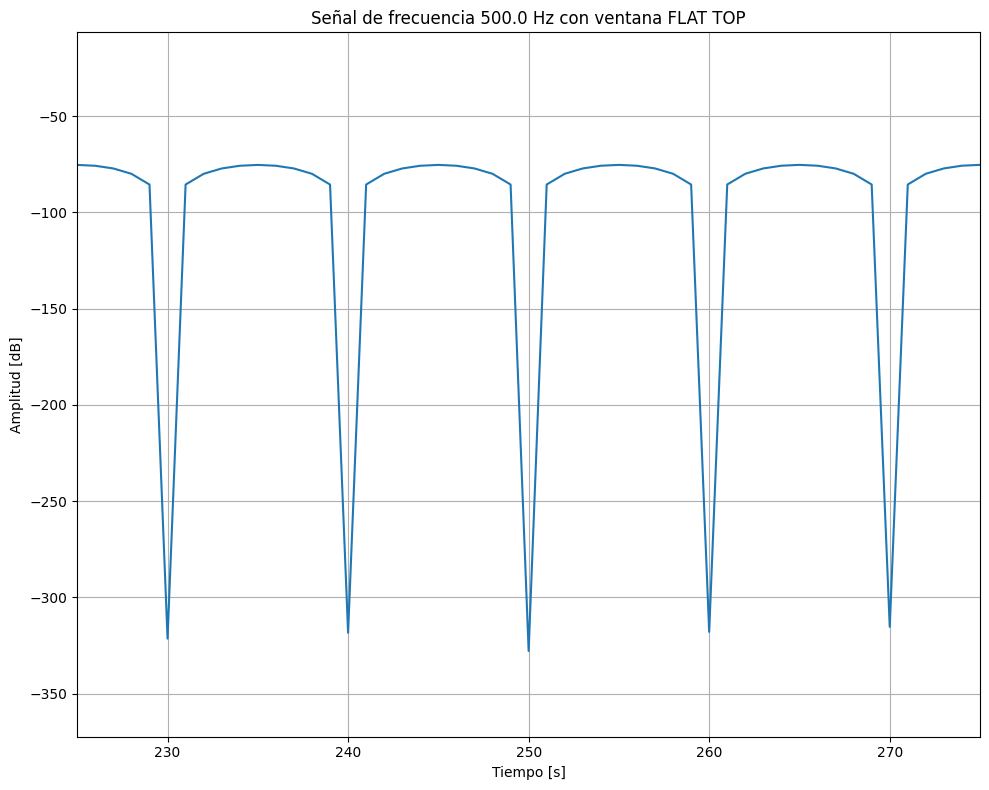

In [ ]:
##### Variables
vmax = 2**.5    # Vpico
ph = 0          # Fase inicial
N = 2000        # Cant Muestras
fs = 2000       # Freq muestreo
zeros = 9*N

delta_f = fs/N
freq = N/8 * delta_f   # Freq

##### Funciones
xx, tt = mi_funcion_sen(vmax, ff=freq, ph=ph,  nn=N, fs=fs)

## FFT
xx_fft = np.fft.fft(xx, axis=0, n=(N + zeros) )/(N + zeros)
abs_xx_fft = mod_db(xx_fft) 

plt.figure(figsize=(10,8))
plt.plot(abs_xx_fft)
plt.xlim(freq*.9, freq*1.1)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [dB]")
plt.title(f"Señal de frecuencia {freqs[0]} Hz con ventana Zero-Padding")
plt.tight_layout()
plt.grid()

plt.show()

